In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
sns.set_style('darkgrid')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [19]:
df_train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

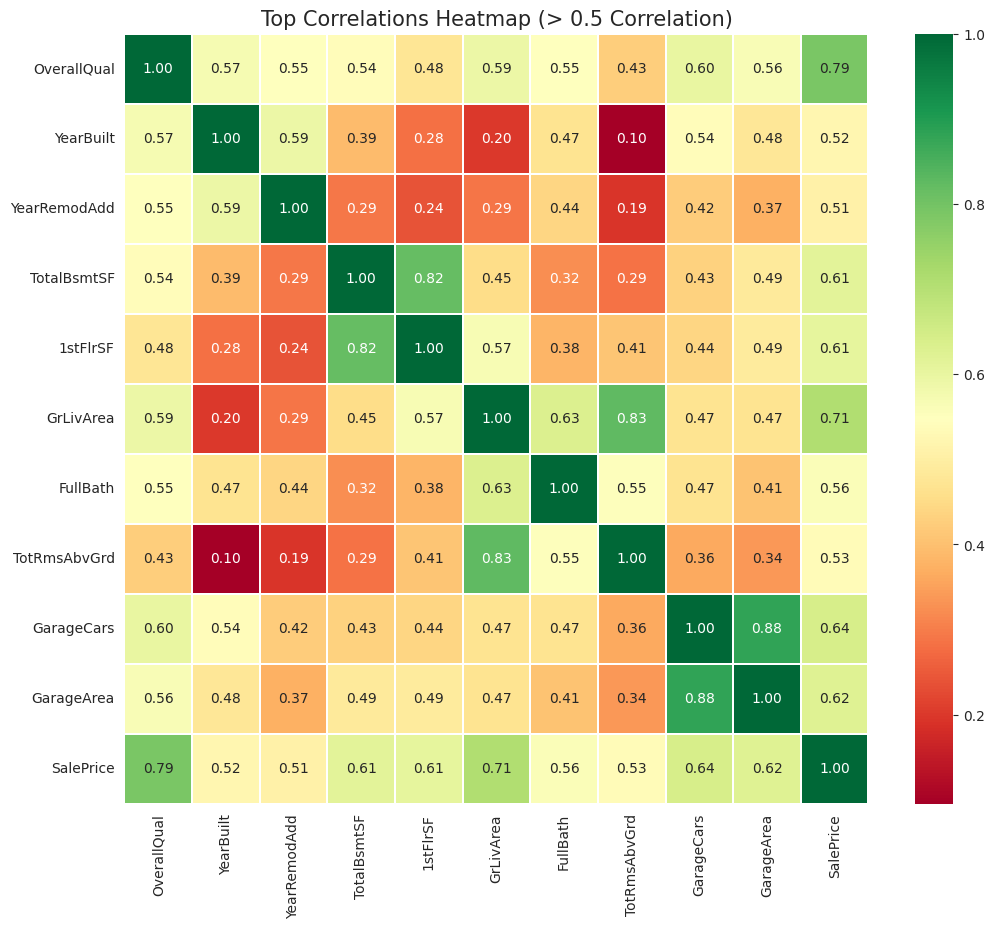

In [20]:
numeric_df = df_train.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

plt.figure(figsize=(12, 10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.2)
plt.title('Top Correlations Heatmap (> 0.5 Correlation)', fontsize=15)
plt.show()

In [21]:
Q1 = df_train['SalePrice'].quantile(0.25)
Q3 = df_train['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mean_val = df_train['SalePrice'].mean()
median_val = df_train['SalePrice'].median()
outliers = df_train[(df_train['SalePrice'] < lower_bound) | (df_train['SalePrice'] > upper_bound)]

print(f"Mean Price: {mean_val:.2f}")
print(f"Median Price: {median_val:.2f}")
print(f"---" * 5)
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Total Outliers detected: {len(outliers)}")

Mean Price: 180921.20
Median Price: 163000.00
---------------
Lower Bound: 3937.50
Upper Bound: 340037.50
Total Outliers detected: 61


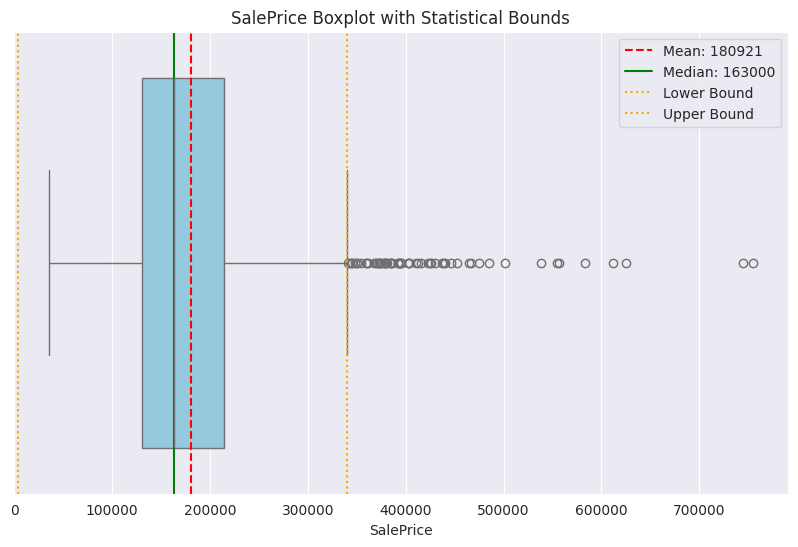

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_train['SalePrice'], color='skyblue')

plt.axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='g', linestyle='-', label=f'Median: {median_val:.0f}')
plt.axvline(lower_bound, color='orange', linestyle=':', label='Lower Bound')
plt.axvline(upper_bound, color='orange', linestyle=':', label='Upper Bound')

plt.title('SalePrice Boxplot with Statistical Bounds')
plt.legend()
plt.show()

In [23]:
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars',
                     'TotalBsmtSF', 'FullBath', 'YearBuilt', 'Neighborhood']

X = df_train[selected_features].copy()
y = df_train['SalePrice']

numeric_features     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features    : {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Missing values:\n{X.isnull().sum()}")


Numeric features    : ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
Categorical features: ['Neighborhood']
Missing values:
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
Neighborhood    0
dtype: int64


In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"\nTraining size  : {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")


Training size  : 1022
Validation size: 438


In [25]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,  numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [26]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor',    LinearRegression())
])

In [27]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'TotalBsmtSF',
                                                   'FullBath', 'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Neighborhood'])])),
                ('regressor', LinearRegression())])

In [28]:
y_pred = model.predict(X_val)

In [29]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-squared (R2): 0.8325
Mean Absolute Error (MAE): $21692.75
Root Mean Squared Error (RMSE): $34186.25


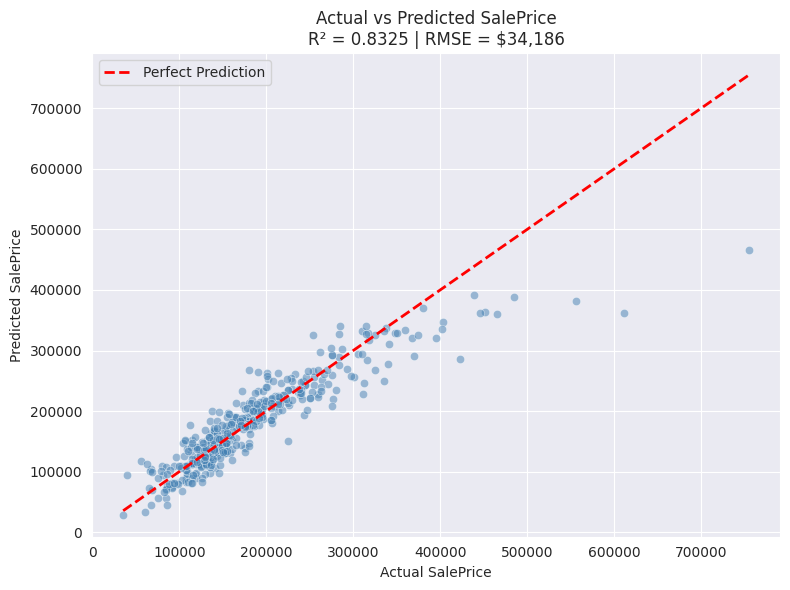

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title(f'Actual vs Predicted SalePrice\nR² = {r2:.4f} | RMSE = ${rmse:,.0f}')
plt.legend()
plt.tight_layout()
plt.show()